# Ayudantía 8 — Solución
## Diseño Experimental Factorial y Bloqueo
**IIQ3402 · Diseño Estadístico** | Ayudante: Gabriel Miranda

## Imports y carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.graphics.factorplots import interaction_plot
from statsmodels.formula.api import ols
import statsmodels.api as sm
from scipy import stats

data = np.array([
    [0, 0, 0, -4.746421], [0, 0, 0, -5.069891], [0, 0, 0, -4.995077],
    [1, 0, 0,  3.061127], [1, 0, 0,  2.881662], [1, 0, 0,  3.000310],
    [0, 1, 0, -5.500134], [0, 1, 0, -5.763209], [0, 1, 0, -5.347351],
    [1, 1, 0,  2.590075], [1, 1, 0,  2.406186], [1, 1, 0,  2.474268],
    [0, 2, 0, -5.924205], [0, 2, 0, -6.039203], [0, 2, 0, -6.036412],
    [1, 2, 0,  1.782014], [1, 2, 0,  2.083187], [1, 2, 0,  2.018582],
    [0, 0, 1, -6.958831], [0, 0, 1, -7.228979], [0, 0, 1, -6.752395],
    [1, 0, 1,  1.023150], [1, 0, 1,  0.941929], [1, 0, 1,  1.304361],
    [0, 1, 1, -2.506808], [0, 1, 1, -2.717602], [0, 1, 1, -2.560784],
    [1, 1, 1,  5.156753], [1, 1, 1,  5.657409], [1, 1, 1,  5.437529],
    [0, 2, 1,  1.888617], [0, 2, 1,  2.160871], [0, 2, 1,  1.752339],
    [1, 2, 1, 10.080314], [1, 2, 1,  9.690338], [1, 2, 1,  9.900676],
])

df = pd.DataFrame(data, columns=['x1', 'x2', 'x3', 'y'])
df[['x1', 'x2', 'x3']] = df[['x1', 'x2', 'x3']].astype('int').astype('category')

print(f"Diseño: {df['x1'].nunique()} x {df['x2'].nunique()} x {df['x3'].nunique()} "
      f"con {df.groupby(['x1','x2','x3'], observed=True).size().iloc[0]} réplicas")
print(f"Total observaciones: {len(df)}")
df.groupby(['x1','x2','x3'], observed=True)['y'].mean()

Diseño: 2 x 3 x 2 con 3 réplicas
Total observaciones: 36


x1  x2  x3
0   0   0    -4.937130
        1    -6.980068
    1   0    -5.536898
        1    -2.595065
    2   0    -5.999940
        1     1.933942
1   0   0     2.981033
        1     1.089813
    1   0     2.490176
        1     5.417230
    2   0     1.961261
        1     9.890443
Name: y, dtype: float64

---
## Parte I — Interaction Plots y ANOVA

### a) Interaction Plots

Graficamos los tres pares de factores en una sola figura.  
**Regla de lectura:** líneas **paralelas** → sin interacción; líneas que se **cruzan** → interacción presente.

/Users/gabbi/miniconda3/envs/SaaLab/lib/python3.12/site-packages/statsmodels/graphics/factorplots.py:127: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data = data.groupby(["trace", "x"]).aggregate(func).reset_index()
/Users/gabbi/miniconda3/envs/SaaLab/lib/python3.12/site-packages/statsmodels/graphics/factorplots.py:145: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (values, group) in enumerate(plot_data.groupby("trace")):
/Users/gabbi/miniconda3/envs/SaaLab/lib/python3.12/site-packages/statsmodels/graphics/factorplots.py:127: FutureWarning: The default of observed=False is deprecated and will be

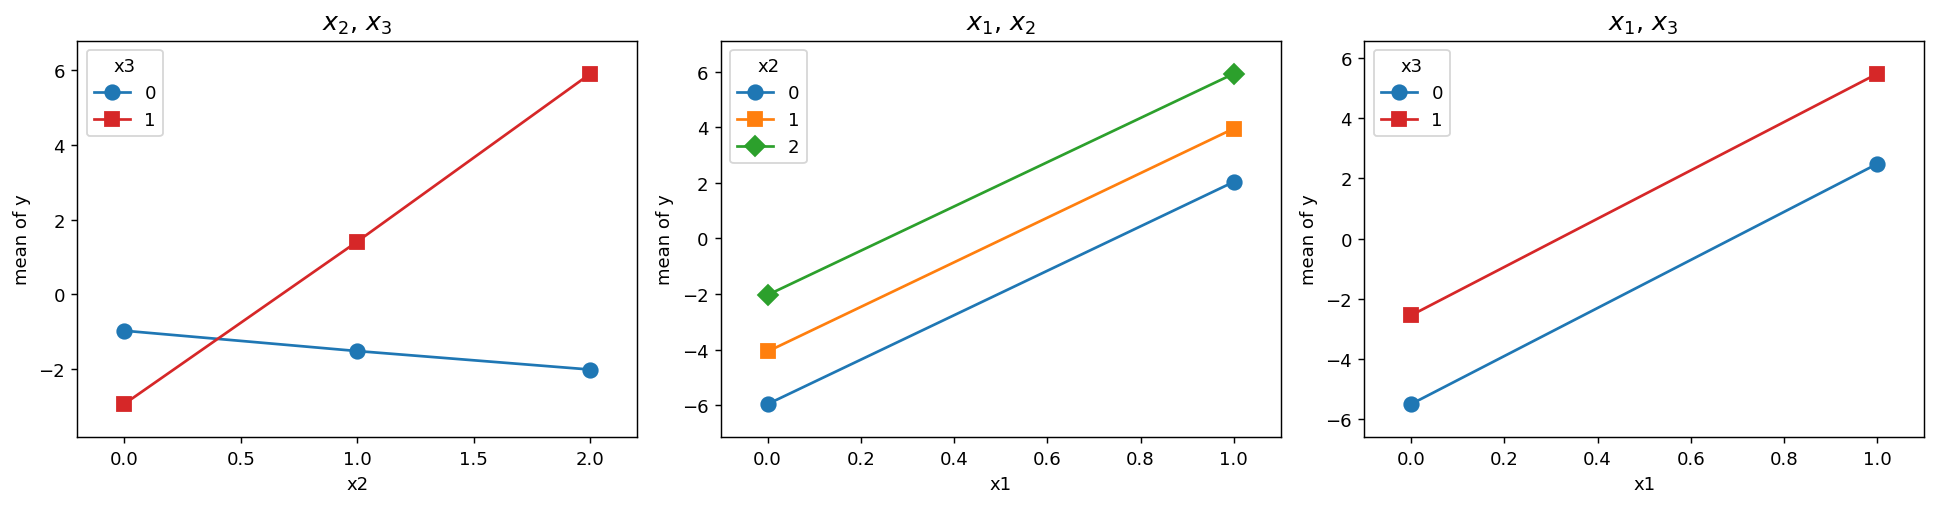

In [2]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4), dpi=130)

pairs = [
    ('x2', 'x3', ['tab:blue', 'tab:red'], '$x_2$ x $x_3$'),
    ('x1', 'x2', ['tab:blue', 'tab:orange', 'tab:green'],'$x_1$ x $x_2$'),
    ('x1', 'x3', ['tab:blue', 'tab:red'], '$x_1$ x $x_3$'),
]
# x2, x3
interaction_plot(
    x=df[pairs[0][0]], # x=df['x2'],
    trace=df[pairs[0][1]], # trace=df['x3'],
    response=df['y'], 
    ax=ax[0],
    colors=pairs[0][2], 
    markers=['o', 's'], ms=8,
)

# x1, x2
interaction_plot(
    x=df[pairs[1][0]], # x=df['x1'],
    trace=df[pairs[1][1]], # trace=df['x2'],
    response=df['y'],
    ax=ax[1],
    colors=pairs[1][2],
    markers=['o', 's', 'D'], ms=8,
)

# x1, x3
interaction_plot(   
    x=df[pairs[2][0]], # x=df['x1'],
    trace=df[pairs[2][1]], # trace=df['x3'],
    response=df['y'],
    ax=ax[2],
    colors=pairs[2][2], 
    markers=['o', 's'], ms=8,
)

ax[0].set_title('$x_2$, $x_3$', fontsize=14)
ax[1].set_title('$x_1$, $x_2$', fontsize=14)
ax[2].set_title('$x_1$, $x_3$ ', fontsize=14)

plt.tight_layout()
plt.show()

### b) ANOVA Factorial Completo (Tipo II)

Ajustamos el modelo completo con todos los efectos e interacciones.

In [13]:
modelo_completo = ols('y ~ C(x1) * C(x2) * C(x3)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_completo, typ=2)

# Agregar columna de significancia para facilitar la lectura

tabla_anova

,sum_sq,df,F,PR(>F)
C(x1),574.683513,1.0,18690.706091,3.190861e-36
C(x2),91.654323,2.0,1490.458644,6.738211e-26
C(x3),79.190359,1.0,2575.545827,6.207770e-26
C(x1):C(x2),0.005596,2.0,0.091007,9.133251e-01
C(x1):C(x3),0.004372,1.0,0.142186,7.094313e-01
C(x2):C(x3),146.978321,2.0,2390.123029,2.415639e-28
C(x1):C(x2):C(x3),0.013073,2.0,0.212583,8.099991e-01
Residual,0.737928,24.0,NaN,NaN


### c) Diagnóstico de residuos

Verificamos los supuestos del ANOVA: **normalidad** (Q-Q plot + Shapiro-Wilk) y **homocedasticidad** (residuos vs. ajustados + Breusch-Pagan).

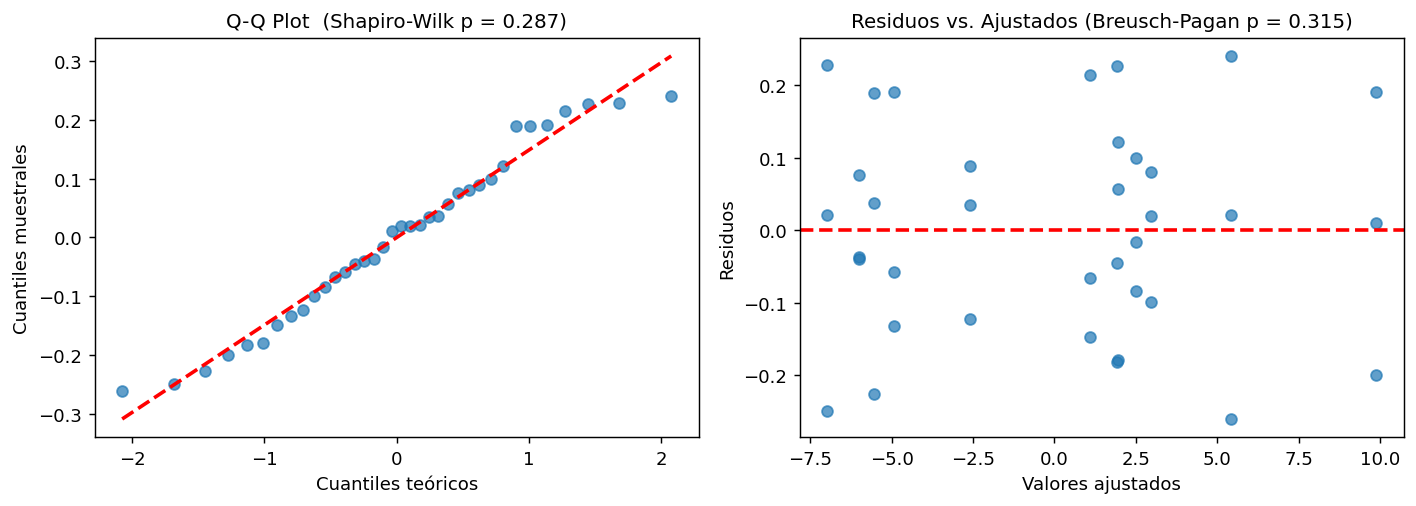

In [4]:
residuos = modelo_completo.resid
ajustados = modelo_completo.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=130)

# Q-Q plot
(osm, osr), (slope, intercept, _) = stats.probplot(residuos)
axes[0].plot(osm, osr, 'o', alpha=0.7)
axes[0].plot(osm, slope * osm + intercept, 'r--', lw=2)
p_sw = stats.shapiro(residuos)[1]
axes[0].set_title(f'Q-Q Plot  (Shapiro-Wilk p = {p_sw:.3f})', fontsize=11)
axes[0].set_xlabel('Cuantiles teóricos'); axes[0].set_ylabel('Cuantiles muestrales')

# Residuos vs. Ajustados
axes[1].scatter(ajustados, residuos, alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--', lw=2)
p_bp = sm.stats.diagnostic.het_breuschpagan(residuos, modelo_completo.model.exog)[1]
axes[1].set_title(f'Residuos vs. Ajustados (Breusch-Pagan p = {p_bp:.3f})', fontsize=11)
axes[1].set_xlabel('Valores ajustados'); axes[1].set_ylabel('Residuos')

plt.tight_layout()
plt.show()

---
## Parte II — Estimación de Efectos

Los efectos se calculan como desviaciones respecto a la gran media $\hat{\mu}$:

$$\hat{\tau}_i = \bar{y}_{i\cdot\cdot} - \hat{\mu} \qquad \widehat{(\tau\beta)}_{ij} = \bar{y}_{ij\cdot} - \bar{y}_{i\cdot\cdot} - \bar{y}_{\cdot j\cdot} + \hat{\mu}$$

In [5]:
mu = df['y'].mean()

# Efectos principales
ef_x1 = df.groupby('x1', observed=True)['y'].mean() - mu
ef_x2 = df.groupby('x2', observed=True)['y'].mean() - mu
ef_x3 = df.groupby('x3', observed=True)['y'].mean() - mu

# Interacciones
med_x1x2 = df.groupby(['x1','x2'], observed=True)['y'].mean()
med_x1x3 = df.groupby(['x1','x3'], observed=True)['y'].mean()
med_x2x3 = df.groupby(['x2','x3'], observed=True)['y'].mean()

int_x1x2 = med_x1x2 - ef_x1 - ef_x2 - mu
int_x1x3 = med_x1x3 - ef_x1 - ef_x3 - mu
int_x2x3 = med_x2x3 - ef_x2 - ef_x3 - mu

print("Efectos principales:")
print("x1:\n", ef_x1.round(3))
print("\nx2:\n", ef_x2.round(3))
print("\nx3:\n", ef_x3.round(3))    
print("\nInteracciones:")
print("x1, x2:\n", int_x1x2.round(3))
print("\nx1, x3:\n", int_x1x3.round(3))
print("\nx2, x3:\n", int_x2x3.round(3))

Efectos principales:
x1:
 x1
0   -3.995
1    3.995
Name: y, dtype: float64

x2:
 x2
0   -1.938
1   -0.032
2    1.970
Name: y, dtype: float64

x3:
 x3
0   -1.483
1    1.483
Name: y, dtype: float64

Interacciones:
x1, x2:
 x1  x2
0   0    -0.002
    1    -0.014
    2     0.016
1   0     0.002
    1     0.014
    2    -0.016
Name: y, dtype: float64

x1, x3:
 x1  x3
0   0     0.011
    1    -0.011
1   0    -0.011
    1     0.011
Name: y, dtype: float64

x2, x3:
 x2  x3
0   0     2.467
    1    -2.467
1   0     0.016
    1    -0.016
2   0    -2.483
    1     2.483
Name: y, dtype: float64


---
## Parte III — ANOVA con Bloqueo en $x_1$

Al tratar $x_1$ como variable de bloqueo, su variabilidad se *separa* del error experimental. Esto reduce el $MS_\text{Error}$ y aumenta la potencia del test para los efectos de tratamiento.



In [ ]:
def anova_2f_block(df, var1=None, var2=None, y=None, block=None):
    """
    ANOVA de dos factores con diseno en bloques completos aleatorizados (RCBD).

    Implementa las formulas de suma de cuadrados de Montgomery (2017), Cap. 5.6.
    Requiere una sola replicacion por celda (sin repeticiones dentro del bloque).

    Parametros
    ----------
    df    : DataFrame con los datos (sin la columna Rep).
    var1  : str, nombre del primer factor (columna categorica).
    var2  : str, nombre del segundo factor (columna categorica).
    y     : str, nombre de la variable respuesta.
    block : str, nombre de la variable de bloqueo (columna categorica).

    Retorna
    -------
    DataFrame con columnas [Source, SS, df, MS, F, p-value].
    El bloque y el error no tienen F ni p-value (el bloque absorbe variabilidad, no se prueba).

    Formulas (Montgomery, 2017, Sec. 5.6)
    ------
    CF = (sum y)^2 / (a*b*n)                          # factor de correccion
    SS_A  = (1/(b*n)) * sum(sum_A_i^2) - CF
    SS_B  = (1/(a*n)) * sum(sum_B_j^2) - CF
    SS_AB = (1/n) * sum(sum_AB_ij^2) - CF - SS_A - SS_B
    SS_block = (1/(a*b)) * sum(sum_block_k^2) - CF
    SS_E = SS_T - SS_A - SS_B - SS_AB - SS_block
    df_error = (a*b - 1)*(n - 1)
    """
    if var1 is None or var2 is None or y is None or block is None:
        raise ValueError("var1, var2, y and block must be defined")

    grand_sum = df[y].sum()

    sum_A      = df.groupby(var1)[y].sum()
    sum_B      = df.groupby(var2)[y].sum()
    sum_AB     = df.groupby([var1, var2])[y].sum()
    sum_blocks = df.groupby(block)[y].sum()

    a = len(df[var1].unique())
    b = len(df[var2].unique())
    n = len(df[block].unique())

    mean_sum_sq = grand_sum**2 / (a * b * n)

    sum_of_squares_A     = (1 / (b * n)) * (sum_A**2).sum() - mean_sum_sq
    sum_of_squares_B     = (1 / (a * n)) * (sum_B**2).sum() - mean_sum_sq
    sum_subtotals        = (1 / n) * (sum_AB**2).sum() - mean_sum_sq
    sum_of_squares_AB    = sum_subtotals - sum_of_squares_A - sum_of_squares_B
    sum_of_squares_block = (1 / (a * b)) * (sum_blocks**2).sum() - mean_sum_sq
    sum_of_squares_total = np.sum(df[y] ** 2) - mean_sum_sq
    sum_of_squares_error = (sum_of_squares_total - sum_of_squares_A
                            - sum_of_squares_B - sum_of_squares_AB
                            - sum_of_squares_block)

    df_A     = a - 1
    df_B     = b - 1
    df_AB    = (a - 1) * (b - 1)
    df_block = n - 1
    df_total = len(df) - 1
    df_error = (a * b - 1) * (n - 1)

    MS_A     = sum_of_squares_A / df_A
    MS_B     = sum_of_squares_B / df_B
    MS_AB    = sum_of_squares_AB / df_AB
    MS_block = sum_of_squares_block / df_block
    MS_error = sum_of_squares_error / df_error
    MS_T     = sum_of_squares_total / df_total

    F_A  = MS_A / MS_error
    F_B  = MS_B / MS_error
    F_AB = MS_AB / MS_error

    p_val_A  = stats.f.sf(F_A,  df_A,  df_error) # sf = 1 - cdf
    p_val_B  = stats.f.sf(F_B,  df_B,  df_error)
    p_val_AB = stats.f.sf(F_AB, df_AB, df_error)

    rows = [
        [var1, sum_of_squares_A, df_A,     MS_A,     F_A,  p_val_A],
        [var2, sum_of_squares_B,     df_B,     MS_B,     F_B,  p_val_B],
        [f"{var1}*{var2}", sum_of_squares_AB, df_AB,    MS_AB,    F_AB, p_val_AB],
        [block, sum_of_squares_block, df_block, MS_block, "-",  "-"],
        ["Error", sum_of_squares_error, df_error, MS_error, "-",  "-"],
        ["Total",       sum_of_squares_total, df_total, MS_T,     "-",  "-"],
    ]
    results = pd.DataFrame(rows, columns=["Source", "SS", "df", "MS", "F", "p-value"])
    return results.round(5)

In [7]:
# Tomar una sola réplica por celda (la primera)
df['rep'] = df.groupby(['x1','x2','x3'], observed=True).cumcount() + 1
rep1 = df[df['rep'] == 1].drop(columns='rep').copy()

print(f"Observaciones para RCBD: {len(rep1)}  "
      f"({rep1['x1'].nunique()} bloques x {rep1['x2'].nunique()} x {rep1['x3'].nunique()} tratamientos)")
tabla_bloques = anova_2f_block(rep1, var1='x2', var2='x3', y='y', block='x1')
tabla_bloques

Observaciones para RCBD: 12  (2 bloques x 3 x 2 tratamientos)


/var/folders/d4/fcz_093s76vfkprz49zjtkmc0000gn/T/ipykernel_81789/4057094135.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sum_A      = df.groupby(var1)[y].sum()
/var/folders/d4/fcz_093s76vfkprz49zjtkmc0000gn/T/ipykernel_81789/4057094135.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sum_B      = df.groupby(var2)[y].sum()
/var/folders/d4/fcz_093s76vfkprz49zjtkmc0000gn/T/ipykernel_81789/4057094135.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the fu

,Source,SS,df,MS,F,p-value
0,x2,29.85095,2,14.92547,649.763595,0.000001
1,x3,25.29018,1,25.29018,1100.979263,0.0
2,x2*x3,51.84674,2,25.92337,1128.544575,0.0
3,x1,187.55574,1,187.55574,-,-
4,Error,0.11485,5,0.02297,-,-
5,Total,294.65846,11,26.78713,-,-


**¿Por qué el bloque no tiene estadístico $F$?**  
En el RCBD sin réplicas dentro del bloque, no hay grados de libertad disponibles para estimar la interacción bloque × tratamiento. El término de error *asume* que esa interacción es cero y la usa como denominador para los $F$ de los tratamientos. Si el bloque interactuara con los tratamientos, el $MS_\text{Error}$ quedaría inflado y perderíamos potencia.

### Comparación: con bloqueo vs. sin bloqueo

In [9]:
tabla_bloques

,Source,SS,df,MS,F,p-value
0,x2,29.85095,2,14.92547,649.763595,0.000001
1,x3,25.29018,1,25.29018,1100.979263,0.0
2,x2*x3,51.84674,2,25.92337,1128.544575,0.0
3,x1,187.55574,1,187.55574,-,-
4,Error,0.11485,5,0.02297,-,-
5,Total,294.65846,11,26.78713,-,-


In [14]:
MS_sin = modelo_completo.mse_resid          # Parte I
df_sin = modelo_completo.df_resid

# MS_Error con bloqueo (fila 'Error' de la tabla)
fila_error = tabla_bloques[tabla_bloques['Source'] == 'Error'].iloc[0]
MS_con = float(fila_error['MS'])
df_con = int(fila_error['df'])


print(f"{'Modelo':<30} {'MS_Error':>10}  {'df_Error':>8}")

print(f"{'Sin bloqueo (Parte I)':<30} {MS_sin:>10.5f}  {int(df_sin):>8}")
print(f"{'Con bloqueo x1 (Parte III)':<30} {MS_con:>10.5f}  {df_con:>8}")
reduccion = (1 - MS_con / MS_sin) * 100
print(f"Reducción en MS_Error: {reduccion:.1f}%")



Modelo                           MS_Error  df_Error
Sin bloqueo (Parte I)             0.03075        24
Con bloqueo x1 (Parte III)        0.02297         5
Reducción en MS_Error: 25.3%
